In [1]:
# Cella 1 - Imports e configurazione
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Optional, Tuple

import csv
import math
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

In [2]:
# Cella 2 - Config principale (contextual training 2D)
@dataclass
class Config:
    data_dir: Path = Path(".")
    pc_file: str = "PescettiPC.asc"
    bs_file: str = "PescettiBS.asc"
    as_file: str = "PescettiAS.asc"

    # Rapporto verificato: 1000 righe input per 1 riga target.
    stack_size_input: int = 1000
    stack_mode: str = "sum"   # "sum" o "mean"
    input_mode: str = "pc"    # "pc", "bs", "pcbs"

    # Patch 2D
    patch_size: int = 32        # prova 32 o 64
    patch_stride: int = 16
    use_augmentation: bool = True

    # Training
    seed: int = 42
    batch_size: int = 16
    epochs: int = 20
    lr: float = 1e-4
    loss_name: str = "mse"  # "mse" oppure "l1"
    val_split: float = 0.2
    num_workers: int = 0
    device: str = "cuda" if torch.cuda.is_available() else "cpu"


CFG = Config(data_dir=Path("."))
torch.manual_seed(CFG.seed)
np.random.seed(CFG.seed)
print(f"Device: {CFG.device}")

Device: cpu


In [3]:
# Cella 3 - DataLoader modulare (immagine 2D completa)
class PescettiDataLoader:
    def __init__(self, cfg: Config):
        self.cfg = cfg
        self.pc_path = cfg.data_dir / cfg.pc_file
        self.bs_path = cfg.data_dir / cfg.bs_file
        self.as_path = cfg.data_dir / cfg.as_file

    @staticmethod
    def _read_rows(path: Path) -> np.ndarray:
        rows = []
        with path.open("r", newline="") as f:
            reader = csv.reader(f)
            for row in reader:
                vals = [v for v in row if v != ""]
                if len(vals) <= 1:
                    continue
                rows.append(np.array(vals[1:], dtype=np.float32))  # scarto metadato
        if not rows:
            raise ValueError(f"Nessun dato valido letto da {path}")
        return np.stack(rows, axis=0)

    def _stack_input_rows(self, x: np.ndarray, n_target_rows: int) -> np.ndarray:
        n_input_rows, n_pix = x.shape
        k = self.cfg.stack_size_input
        expected = n_target_rows * k
        if n_input_rows != expected:
            raise ValueError(
                f"Input rows={n_input_rows} incompatibile con target rows={n_target_rows} e stack_size={k}"
            )

        # Formato corretto: sequenza temporale di frame completi.
        # x -> (1000 frame, 189 righe, 253 pixel)
        x_blocks = x.reshape(k, n_target_rows, n_pix)
        if self.cfg.stack_mode == "sum":
            return x_blocks.sum(axis=0)
        if self.cfg.stack_mode == "mean":
            return x_blocks.mean(axis=0)
        raise ValueError("stack_mode deve essere 'sum' o 'mean'")

    def load_full_images(self):
        as_img = self._read_rows(self.as_path)   # (189,253)
        pc_rows = self._read_rows(self.pc_path)  # (189000,253)
        bs_rows = self._read_rows(self.bs_path)  # (189000,253)

        if as_img.shape[1] != pc_rows.shape[1] or as_img.shape[1] != bs_rows.shape[1]:
            raise ValueError(
                f"Numero pixel disallineato: AS={as_img.shape[1]} PC={pc_rows.shape[1]} BS={bs_rows.shape[1]}"
            )

        pc_img = self._stack_input_rows(pc_rows, as_img.shape[0])
        bs_img = self._stack_input_rows(bs_rows, as_img.shape[0])

        print(f"AS image shape: {as_img.shape}")
        print(f"PC stacked image shape: {pc_img.shape}")
        print(f"BS stacked image shape: {bs_img.shape}")
        return pc_img, bs_img, as_img

In [4]:
# Cella 4 - PreProcessor modulare
class PreProcessor:
    @staticmethod
    def anscombe(x: np.ndarray) -> np.ndarray:
        # Stabilizzazione varianza per rumore Poisson.
        if x is None:
            raise ValueError("PreProcessor.anscombe received None")
        x = np.asarray(x, dtype=np.float32)
        x = np.maximum(x, 0.0)
        return 2.0 * np.sqrt(x + 3.0 / 8.0)

    @staticmethod
    def minmax_norm(x: np.ndarray, eps: float = 1e-8):
        mn = x.min()
        mx = x.max()
        return (x - mn) / (mx - mn + eps), float(mn), float(mx)

    @staticmethod
    def minmax_apply(x: np.ndarray, mn: float, mx: float, eps: float = 1e-8):
        return (x - mn) / (mx - mn + eps)

In [5]:
# Cella 5 - ModelBuilder (U-Net 2D classica tipo CARE)
class DoubleConv(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class UNet2D(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, base=32):
        super().__init__()
        self.enc1 = DoubleConv(in_ch, base)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = DoubleConv(base, base * 2)
        self.pool2 = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(base * 2, base * 4)

        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(base * 4, base * 2)
        self.up1 = nn.ConvTranspose2d(base * 2, base, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(base * 2, base)
        self.outc = nn.Conv2d(base, out_ch, kernel_size=1)

    @staticmethod
    def _match_size(x: torch.Tensor, ref: torch.Tensor) -> torch.Tensor:
        if x.shape[-2:] != ref.shape[-2:]:
            x = torch.nn.functional.interpolate(x, size=ref.shape[-2:], mode="bilinear", align_corners=False)
        return x

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        b = self.bottleneck(self.pool2(e2))

        d2 = self.up2(b)
        d2 = self._match_size(d2, e2)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = self._match_size(d1, e1)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)
        return self.outc(d1)

In [6]:
# Cella 6 - Dataset patch 2D con augmentation + SPATIAL SPLIT
class PatchDataset(Dataset):
    def __init__(self, x_img: np.ndarray, y_img: np.ndarray, coords, patch_size: int, augment: bool = False):
        self.x_img = torch.from_numpy(x_img).float()
        self.y_img = torch.from_numpy(y_img).float()
        self.coords = coords
        self.patch_size = patch_size
        self.augment = augment

    def __len__(self):
        return len(self.coords)

    def _augment_pair(self, x: torch.Tensor, y: torch.Tensor):
        # Rotazioni 90/180/270 e flip orizzontale/verticale applicati in coppia.
        if np.random.rand() < 0.5:
            k = int(np.random.randint(0, 4))
            x = torch.rot90(x, k=k, dims=(0, 1))
            y = torch.rot90(y, k=k, dims=(0, 1))
        if np.random.rand() < 0.5:
            x = torch.flip(x, dims=(1,))
            y = torch.flip(y, dims=(1,))
        if np.random.rand() < 0.5:
            x = torch.flip(x, dims=(0,))
            y = torch.flip(y, dims=(0,))
        return x, y

    def __getitem__(self, idx):
        r0, c0 = self.coords[idx]
        ps = self.patch_size
        x_patch = self.x_img[r0:r0 + ps, c0:c0 + ps]
        y_patch = self.y_img[r0:r0 + ps, c0:c0 + ps]

        if self.augment:
            x_patch, y_patch = self._augment_pair(x_patch, y_patch)

        return x_patch.unsqueeze(0), y_patch.unsqueeze(0)  # [1,ps,ps]


def generate_patch_coords_in_row_range(h: int, w: int, ps: int, stride: int, row_start: int, row_end_exclusive: int):
    # Crea patch SOLO nella finestra verticale [row_start, row_end_exclusive).
    local_h = row_end_exclusive - row_start
    if local_h < ps:
        raise ValueError(f"Area righe troppo piccola per patch_size={ps}: {local_h}")

    rows_local = list(range(0, local_h - ps + 1, stride))
    cols = list(range(0, w - ps + 1, stride))
    if rows_local[-1] != local_h - ps:
        rows_local.append(local_h - ps)
    if cols[-1] != w - ps:
        cols.append(w - ps)

    # Trasla le coordinate locali sul sistema globale dell'immagine intera.
    rows_global = [row_start + r for r in rows_local]
    return [(r, c) for r in rows_global for c in cols]


loader = PescettiDataLoader(CFG)
pc_img, bs_img, as_img = loader.load_full_images()

if CFG.input_mode.lower() == "pc":
    x_raw = pc_img
elif CFG.input_mode.lower() == "bs":
    x_raw = bs_img
elif CFG.input_mode.lower() == "pcbs":
    x_raw = 0.5 * (pc_img + bs_img)
else:
    raise ValueError("input_mode deve essere 'pc', 'bs' o 'pcbs'")

y_raw = as_img

# Anscombe PRIMA della normalizzazione [0,1]
x_ans = PreProcessor.anscombe(x_raw)
x_norm, x_min, x_max = PreProcessor.minmax_norm(x_ans)
y_norm, y_min, y_max = PreProcessor.minmax_norm(y_raw)

H, W = x_norm.shape
split_row = 95  # train: 0..94, val/test: 95..188

# Split spaziale netto (no random_split).
train_coords = generate_patch_coords_in_row_range(H, W, CFG.patch_size, CFG.patch_stride, row_start=0, row_end_exclusive=split_row)
val_coords = generate_patch_coords_in_row_range(H, W, CFG.patch_size, CFG.patch_stride, row_start=split_row, row_end_exclusive=H)
coords = generate_patch_coords_in_row_range(H, W, CFG.patch_size, CFG.patch_stride, row_start=0, row_end_exclusive=H)

train_dataset = PatchDataset(x_norm, y_norm, train_coords, CFG.patch_size, augment=CFG.use_augmentation)
val_dataset = PatchDataset(x_norm, y_norm, val_coords, CFG.patch_size, augment=False)

train_loader = DataLoader(train_dataset, batch_size=CFG.batch_size, shuffle=True, num_workers=CFG.num_workers)
val_loader = DataLoader(val_dataset, batch_size=CFG.batch_size, shuffle=False, num_workers=CFG.num_workers)

xb0, yb0 = next(iter(train_loader))
print(f"Full image shape: {(H, W)}")
print(f"Spatial split row: {split_row} (train 0..{split_row-1}, val/test {split_row}..{H-1})")
print(f"Patch count: total={len(coords)} train={len(train_dataset)} val={len(val_dataset)}")
print(f"Batch debug shape -> xb: {tuple(xb0.shape)}, yb: {tuple(yb0.shape)}")

AS image shape: (189, 253)
PC stacked image shape: (189, 253)
BS stacked image shape: (189, 253)
Full image shape: (189, 253)
Spatial split row: 95 (train 0..94, val/test 95..188)
Patch count: total=165 train=75 val=75
Batch debug shape -> xb: (16, 1, 32, 32), yb: (16, 1, 32, 32)


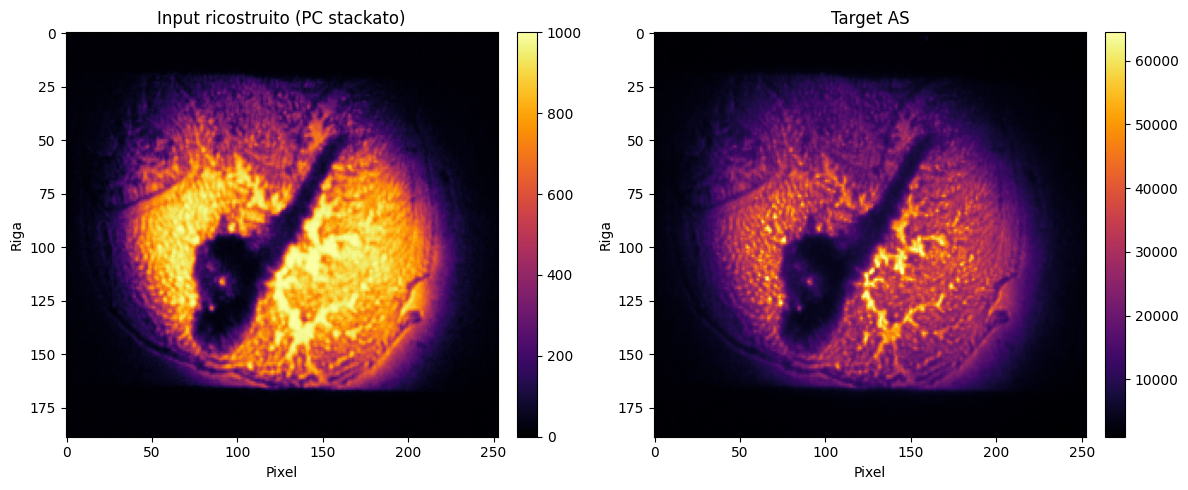

STOP prima della U-Net: verificare coerenza spaziale dell'input stackato.


In [7]:
# Cella 7 - STOP: visualizzazione input ricostruito prima della U-Net
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
im0 = ax[0].imshow(x_raw, cmap="inferno", aspect="auto")
ax[0].set_title(f"Input ricostruito ({CFG.input_mode.upper()} stackato)")
ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Riga")
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

im1 = ax[1].imshow(y_raw, cmap="inferno", aspect="auto")
ax[1].set_title("Target AS")
ax[1].set_xlabel("Pixel")
ax[1].set_ylabel("Riga")
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print("STOP prima della U-Net: verificare coerenza spaziale dell'input stackato.")

In [8]:
# Cella 8 - Trainer 2D
def build_loss(loss_name: str):
    loss_name = loss_name.lower()
    if loss_name == "mse":
        return nn.MSELoss()
    if loss_name == "l1":
        return nn.L1Loss()
    raise ValueError("loss_name deve essere 'mse' o 'l1'")


def evaluate(model, data_loader, criterion, device):
    model.eval()
    total = 0.0
    n = 0
    with torch.no_grad():
        for xb, yb in data_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)
            bs = xb.shape[0]
            total += loss.item() * bs
            n += bs
    return total / max(n, 1)


model = UNet2D(in_ch=1, out_ch=1, base=32).to(CFG.device)
criterion = build_loss(CFG.loss_name)
optimizer = torch.optim.Adam(model.parameters(), lr=CFG.lr)

history = {"train_loss": [], "val_loss": []}

for epoch in range(1, CFG.epochs + 1):
    model.train()
    running = 0.0
    seen = 0
    for xb, yb in train_loader:
        xb = xb.to(CFG.device)
        yb = yb.to(CFG.device)

        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()

        bs = xb.shape[0]
        running += loss.item() * bs
        seen += bs

    train_loss = running / max(seen, 1)
    val_loss = evaluate(model, val_loader, criterion, CFG.device)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    print(f"Epoch {epoch:03d}/{CFG.epochs} | train={train_loss:.6f} | val={val_loss:.6f}")

Epoch 001/20 | train=0.186361 | val=0.075856
Epoch 002/20 | train=0.106299 | val=0.058703
Epoch 003/20 | train=0.071871 | val=0.044460
Epoch 004/20 | train=0.049211 | val=0.031647
Epoch 005/20 | train=0.032819 | val=0.024526
Epoch 006/20 | train=0.023232 | val=0.022894
Epoch 007/20 | train=0.016699 | val=0.023585
Epoch 008/20 | train=0.013216 | val=0.023304
Epoch 009/20 | train=0.012272 | val=0.017291
Epoch 010/20 | train=0.008852 | val=0.012585
Epoch 011/20 | train=0.007111 | val=0.009415
Epoch 012/20 | train=0.006379 | val=0.008208
Epoch 013/20 | train=0.005896 | val=0.007675
Epoch 014/20 | train=0.006571 | val=0.007744
Epoch 015/20 | train=0.005546 | val=0.007326
Epoch 016/20 | train=0.007654 | val=0.007414
Epoch 017/20 | train=0.006115 | val=0.007021
Epoch 018/20 | train=0.004934 | val=0.007992
Epoch 019/20 | train=0.005712 | val=0.007011
Epoch 020/20 | train=0.004119 | val=0.006095


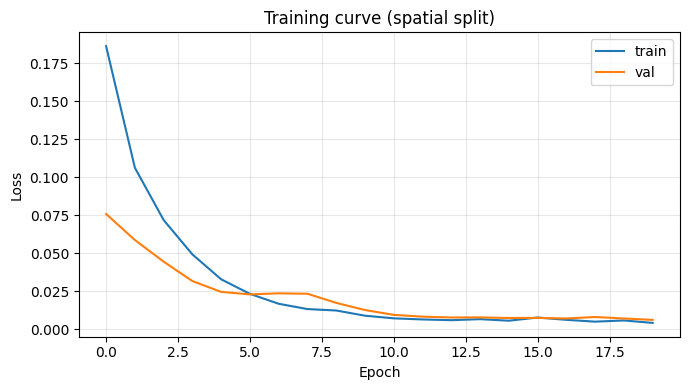

recon_input shape: (189, 253)
recon_pred shape: (189, 253)
recon_gt shape: (189, 253)


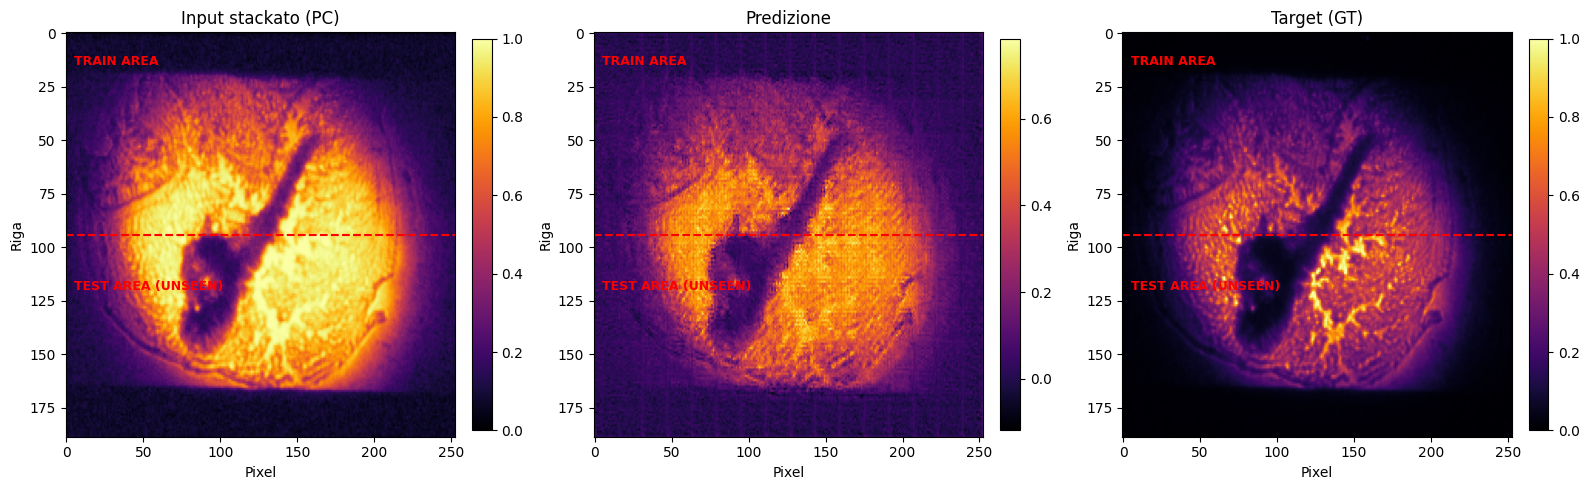

In [9]:
# Cella 9 - Plot curve + ricostruzione full image con confine train/test
plt.figure(figsize=(7, 4))
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training curve (spatial split)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# Ricostruzione dell'immagine 189x253 con media su patch sovrapposte.
model.eval()
acc = np.zeros((H, W), dtype=np.float32)
cnt = np.zeros((H, W), dtype=np.float32)

with torch.no_grad():
    for (r0, c0) in coords:
        x_patch = x_norm[r0:r0 + CFG.patch_size, c0:c0 + CFG.patch_size]
        xb = torch.from_numpy(x_patch).float().unsqueeze(0).unsqueeze(0).to(CFG.device)  # [1,1,ps,ps]
        pred = model(xb).cpu().numpy()[0, 0]
        acc[r0:r0 + CFG.patch_size, c0:c0 + CFG.patch_size] += pred
        cnt[r0:r0 + CFG.patch_size, c0:c0 + CFG.patch_size] += 1.0

recon_input = x_norm
recon_pred = acc / np.maximum(cnt, 1e-8)
recon_gt = y_norm

print(f"recon_input shape: {recon_input.shape}")
print(f"recon_pred shape: {recon_pred.shape}")
print(f"recon_gt shape: {recon_gt.shape}")

fig, ax = plt.subplots(1, 3, figsize=(16, 5))
im0 = ax[0].imshow(recon_input, cmap="inferno", aspect="auto")
ax[0].set_title("Input stackato (PC)")
ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Riga")
ax[0].axhline(94, color="red", linestyle="--", linewidth=1.5)
ax[0].text(5, 15, "TRAIN AREA", color="red", fontsize=9, weight="bold")
ax[0].text(5, 120, "TEST AREA (UNSEEN)", color="red", fontsize=9, weight="bold")
plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

im1 = ax[1].imshow(recon_pred, cmap="inferno", aspect="auto")
ax[1].set_title("Predizione")
ax[1].set_xlabel("Pixel")
ax[1].set_ylabel("Riga")
ax[1].axhline(94, color="red", linestyle="--", linewidth=1.5)
ax[1].text(5, 15, "TRAIN AREA", color="red", fontsize=9, weight="bold")
ax[1].text(5, 120, "TEST AREA (UNSEEN)", color="red", fontsize=9, weight="bold")
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

im2 = ax[2].imshow(recon_gt, cmap="inferno", aspect="auto")
ax[2].set_title("Target (GT)")
ax[2].set_xlabel("Pixel")
ax[2].set_ylabel("Riga")
ax[2].axhline(94, color="red", linestyle="--", linewidth=1.5)
ax[2].text(5, 15, "TRAIN AREA", color="red", fontsize=9, weight="bold")
ax[2].text(5, 120, "TEST AREA (UNSEEN)", color="red", fontsize=9, weight="bold")
plt.colorbar(im2, ax=ax[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [10]:
# Cella 10 - Metriche quantitative su TEST AREA (PSNR / SSIM)
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

split_row = 95  # test area: 95..188

test_input = recon_input[split_row:, :]
test_pred = recon_pred[split_row:, :]
test_gt = recon_gt[split_row:, :]

psnr_input = peak_signal_noise_ratio(test_gt, test_input, data_range=1.0)
ssim_input = structural_similarity(test_gt, test_input, data_range=1.0)

psnr_pred = peak_signal_noise_ratio(test_gt, test_pred, data_range=1.0)
ssim_pred = structural_similarity(test_gt, test_pred, data_range=1.0)

print("=== TEST AREA METRICS (rows 95-188) ===")
print(f"Input  vs GT -> PSNR: {psnr_input:.4f} dB | SSIM: {ssim_input:.6f}")
print(f"Pred   vs GT -> PSNR: {psnr_pred:.4f} dB | SSIM: {ssim_pred:.6f}")
print("--- Delta improvement (Pred - Input) ---")
print(f"Delta PSNR: {psnr_pred - psnr_input:+.4f} dB")
print(f"Delta SSIM: {ssim_pred - ssim_input:+.6f}")

=== TEST AREA METRICS (rows 95-188) ===
Input  vs GT -> PSNR: 11.3198 dB | SSIM: 0.424602
Pred   vs GT -> PSNR: 23.4950 dB | SSIM: 0.591474
--- Delta improvement (Pred - Input) ---
Delta PSNR: +12.1752 dB
Delta SSIM: +0.166872


In [ ]:
# Cella 11 - Studio di ablazione: inferenza incrementale su numero di frame
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

frame_steps = [10, 50, 100, 200, 500, 1000]

# Carica PC raw e ricostruisce il tensore temporale [1000, 189, 253]
pc_rows_raw = loader._read_rows(loader.pc_path)  # [189000, 253]
k_total = CFG.stack_size_input
if pc_rows_raw.shape[0] != k_total * H:
    raise ValueError(f"PC raw rows inattese: {pc_rows_raw.shape[0]} vs {k_total * H}")
pc_frames = pc_rows_raw.reshape(k_total, H, W)   # [1000, 189, 253]

# Ground Truth normalizzata (coerente con training/test)
gt_full = y_norm
gt_test = gt_full[split_row:, :]

results = []
pred_map_by_n = {}

model.eval()
with torch.no_grad():
    for N in frame_steps:
        # Stacking sui primi N frame: [:N, :, :]
        x_sim_raw = pc_frames[:N, :, :].sum(axis=0)  # [189,253]

        # Stesso preprocessing del test: Anscombe + MinMax con scaler del training
        x_sim_ans = PreProcessor.anscombe(x_sim_raw)
        x_sim_norm = PreProcessor.minmax_apply(x_sim_ans, x_min, x_max)

        # Ricostruzione full image via patch overlap-average
        acc_sim = np.zeros((H, W), dtype=np.float32)
        cnt_sim = np.zeros((H, W), dtype=np.float32)

        for (r0, c0) in coords:
            x_patch = x_sim_norm[r0:r0 + CFG.patch_size, c0:c0 + CFG.patch_size]
            xb = torch.from_numpy(x_patch).float().unsqueeze(0).unsqueeze(0).to(CFG.device)
            pred_patch = model(xb).cpu().numpy()[0, 0]
            acc_sim[r0:r0 + CFG.patch_size, c0:c0 + CFG.patch_size] += pred_patch
            cnt_sim[r0:r0 + CFG.patch_size, c0:c0 + CFG.patch_size] += 1.0

        recon_sim = acc_sim / np.maximum(cnt_sim, 1e-8)
        pred_map_by_n[N] = recon_sim

        # Metriche sulla SOLA Test Area (righe 95..188)
        pred_test = recon_sim[split_row:, :]
        psnr = peak_signal_noise_ratio(gt_test, pred_test, data_range=1.0)
        ssim = structural_similarity(gt_test, pred_test, data_range=1.0)

        results.append({"N": N, "PSNR": psnr, "SSIM": ssim})

# Tabella risultati
print("=== Ablation results on TEST AREA (rows 95-188) ===")
for r in results:
    print(f"N={r['N']:4d} | PSNR={r['PSNR']:.4f} dB | SSIM={r['SSIM']:.6f}")

# Plot 1: curve PSNR/SSIM vs N
N_vals = [r["N"] for r in results]
psnr_vals = [r["PSNR"] for r in results]
ssim_vals = [r["SSIM"] for r in results]

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(N_vals, psnr_vals, marker="o", label="PSNR (dB)")
ax1.set_xlabel("Numero di frame (N)")
ax1.set_ylabel("PSNR (dB)")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(N_vals, ssim_vals, marker="s", linestyle="--", label="SSIM", color="tab:orange")
ax2.set_ylabel("SSIM")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")
plt.title("Ablation: prestazione vs numero frame")
plt.tight_layout()
plt.show()

# Plot 2: confronto visivo Test Area per N=50,200,1000 + GT
fig, ax = plt.subplots(1, 4, figsize=(18, 4))
for j, N in enumerate([50, 200, 1000]):
    im = ax[j].imshow(pred_map_by_n[N][split_row:, :], cmap="inferno", aspect="auto")
    ax[j].set_title(f"Pred test area (N={N})")
    ax[j].set_xlabel("Pixel")
    ax[j].set_ylabel("Riga test")
    plt.colorbar(im, ax=ax[j], fraction=0.046, pad=0.04)

im_gt = ax[3].imshow(gt_test, cmap="inferno", aspect="auto")
ax[3].set_title("Ground Truth test area")
ax[3].set_xlabel("Pixel")
ax[3].set_ylabel("Riga test")
plt.colorbar(im_gt, ax=ax[3], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [ ]:
# === ZebraRestorer EdgeMetrics START (helpers) ===
import numpy as np
import torch
import torch.nn.functional as F


def compute_edge_pseudolabel_from_as_patch(
    as_patch: torch.Tensor,
    edge_percentile: float = 98.0,
) -> torch.Tensor:
    """Pseudo-label edges from AS patch using gradient magnitude + percentile threshold.

    Returns a float mask in {0,1} with shape [B,1,H,W].
    """
    # as_patch: [B,1,H,W]
    x = as_patch
    dx = x[:, :, :, 1:] - x[:, :, :, :-1]
    dy = x[:, :, 1:, :] - x[:, :, :-1, :]
    dx = F.pad(dx, (0, 1, 0, 0))
    dy = F.pad(dy, (0, 0, 0, 1))

    mag = torch.sqrt(dx * dx + dy * dy + 1e-12)

    q = edge_percentile / 100.0
    B = mag.shape[0]
    th = torch.quantile(mag.view(B, -1), q, dim=1).view(B, 1, 1, 1)
    edges = (mag >= th).to(torch.float32)
    return edges


def dice_coeff(pred_edges: np.ndarray, gt_edges: np.ndarray, eps: float = 1e-8) -> float:
    """FoM via Dice coefficient on binary edge masks."""
    p = pred_edges.astype(bool)
    g = gt_edges.astype(bool)
    inter = np.logical_and(p, g).sum()
    return float((2.0 * inter + eps) / (p.sum() + g.sum() + eps))


def boundary_f_measure(
    pred_edges: np.ndarray,
    gt_edges: np.ndarray,
    tolerance: int = 2,
    eps: float = 1e-8,
) -> float:
    """BF score using tolerance in pixels (dilation-based precision/recall).

    precision = |pred ∩ dilated(gt)| / |pred|
    recall    = |gt   ∩ dilated(pred)| / |gt|
    BF = 2PR/(P+R)
    """
    if tolerance < 0:
        raise ValueError('tolerance must be >= 0')

    pred = torch.from_numpy(pred_edges.astype(np.float32))[None, None]
    gt = torch.from_numpy(gt_edges.astype(np.float32))[None, None]

    pred_b = pred > 0.5
    gt_b = gt > 0.5

    if tolerance == 0:
        pred_d = pred_b
        gt_d = gt_b
    else:
        k = 2 * tolerance + 1
        pred_d = (F.max_pool2d(pred_b.float(), kernel_size=k, stride=1, padding=tolerance) > 0.5)
        gt_d = (F.max_pool2d(gt_b.float(), kernel_size=k, stride=1, padding=tolerance) > 0.5)

    tp_p = (pred_b & gt_d).sum().item()
    tp_r = (gt_b & pred_d).sum().item()

    p_sum = pred_b.sum().item()
    g_sum = gt_b.sum().item()

    precision = tp_p / max(p_sum, 1.0)
    recall = tp_r / max(g_sum, 1.0)

    bf = (2.0 * precision * recall) / (precision + recall + eps)
    return float(bf)


def binary_edges_for_visualization(edge_mask: np.ndarray) -> np.ndarray:
    """Return an image where edges are black (0) and background is white (1)."""
    img = np.ones_like(edge_mask, dtype=np.float32)
    img[edge_mask.astype(bool)] = 0.0
    return img


print('EdgeMetrics helpers loaded.')


EdgeMetrics helpers loaded.


In [ ]:
# === ZebraRestorer EdgeMetrics START (train EdgeNet CS) ===
# Pipeline CS: EdgeNet addestrata su ricostruzioni UNet del PC.

import torch
from torch.utils.data import DataLoader
import torch.nn as nn

edge_percentile = 98.0
edge_prob_threshold = 0.5
edge_epochs = 8  # stock-ish: ridotto per restare veloce
edge_lr = 1e-4

# Usa UNet già addestrata nel notebook (input_mode di default = 'pc')
if 'model' not in globals():
    raise RuntimeError('Nel notebook non trovo la variabile `model` (UNet PC).')

unet_pc = model
unet_pc.eval()

if 'loader' not in globals():
    raise RuntimeError('Nel notebook non trovo `loader` (PescettiDataLoader).')

# Preferisco riusare se esistono già in globals e non sono None
if (
    'pc_img' in globals() and 'bs_img' in globals() and 'as_img' in globals()
    and pc_img is not None and bs_img is not None and as_img is not None
):
    pass
else:
    pc_img, bs_img, as_img = loader.load_full_images()

# Normalizzazione coerente con il training UNet originale
x_ans_pc = PreProcessor.anscombe(pc_img)
x_norm_pc, x_min_pc, x_max_pc = PreProcessor.minmax_norm(x_ans_pc)

y_raw = as_img
# y_norm deve essere uguale per CS e BS (AS come target)
y_norm, y_min, y_max = PreProcessor.minmax_norm(y_raw)

H, W = x_norm_pc.shape
split_row = 95  # coerente con il notebook

train_coords = generate_patch_coords_in_row_range(H, W, CFG.patch_size, CFG.patch_stride, row_start=0, row_end_exclusive=split_row)
val_coords = generate_patch_coords_in_row_range(H, W, CFG.patch_size, CFG.patch_stride, row_start=split_row, row_end_exclusive=H)

train_dataset_pc = PatchDataset(x_norm_pc, y_norm, train_coords, CFG.patch_size, augment=CFG.use_augmentation)
val_dataset_pc = PatchDataset(x_norm_pc, y_norm, val_coords, CFG.patch_size, augment=False)

train_loader_pc = DataLoader(train_dataset_pc, batch_size=CFG.batch_size, shuffle=True, num_workers=CFG.num_workers)
val_loader_pc = DataLoader(val_dataset_pc, batch_size=CFG.batch_size, shuffle=False, num_workers=CFG.num_workers)

# EdgeNet (piccola encoder-decoder) che predice una mappa edge (logits)
edgenet_cs = UNet2D(in_ch=1, out_ch=1, base=16).to(CFG.device)

bce = nn.BCEWithLogitsLoss()
edge_optim = torch.optim.Adam(edgenet_cs.parameters(), lr=edge_lr)

for epoch in range(1, edge_epochs + 1):
    edgenet_cs.train()
    running = 0.0
    seen = 0

    for xb, yb in train_loader_pc:
        xb = xb.to(CFG.device)
        yb = yb.to(CFG.device)

        with torch.no_grad():
            unet_pred = unet_pc(xb)

        labels = compute_edge_pseudolabel_from_as_patch(yb, edge_percentile=edge_percentile)
        logits = edgenet_cs(unet_pred)

        loss = bce(logits, labels)

        edge_optim.zero_grad()
        loss.backward()
        edge_optim.step()

        bs = xb.shape[0]
        running += loss.item() * bs
        seen += bs

    train_loss = running / max(seen, 1)

    # Val (solo log)
    edgenet_cs.eval()
    v_running = 0.0
    v_seen = 0
    with torch.no_grad():
        for xb, yb in val_loader_pc:
            xb = xb.to(CFG.device)
            yb = yb.to(CFG.device)
            unet_pred = unet_pc(xb)
            labels = compute_edge_pseudolabel_from_as_patch(yb, edge_percentile=edge_percentile)
            logits = edgenet_cs(unet_pred)
            loss = bce(logits, labels)
            bs = xb.shape[0]
            v_running += loss.item() * bs
            v_seen += bs
    val_loss = v_running / max(v_seen, 1)

    print(f'[EdgeNet CS] Epoch {epoch:02d}/{edge_epochs} | train={train_loss:.6f} | val={val_loss:.6f}')

print('EdgeNet CS trained.')


[EdgeNet CS] Epoch 01/8 | train=0.540656 | val=0.586861
[EdgeNet CS] Epoch 02/8 | train=0.532438 | val=0.566485
[EdgeNet CS] Epoch 03/8 | train=0.525536 | val=0.550618
[EdgeNet CS] Epoch 04/8 | train=0.518507 | val=0.538222
[EdgeNet CS] Epoch 05/8 | train=0.512588 | val=0.527694
[EdgeNet CS] Epoch 06/8 | train=0.504722 | val=0.518816
[EdgeNet CS] Epoch 07/8 | train=0.497321 | val=0.508744
[EdgeNet CS] Epoch 08/8 | train=0.492221 | val=0.495626
EdgeNet CS trained.


In [ ]:
# === ZebraRestorer EdgeMetrics START (train EdgeNet BS) ===
# Pipeline BS: UNet addestrata su input BS, poi EdgeNet addestrata su ricostruzioni UNet.

import torch
from torch.utils.data import DataLoader
import torch.nn as nn

edge_percentile = 98.0
edge_prob_threshold = 0.5
edge_epochs = 8
edge_lr = 1e-4

if 'loader' not in globals():
    raise RuntimeError('Nel notebook non trovo `loader`.')

if 'PreProcessor' not in globals() or 'PatchDataset' not in globals():
    raise RuntimeError('Nel notebook mancano PreProcessor/PatchDataset: esegui le celle originali prima di questo blocco.')

# Carica full immagini (PC, BS, AS)
pc_img, bs_img, as_img = loader.load_full_images()

# Target: AS normalizzato (uguale per CS e BS)
y_raw = as_img
y_norm, y_min, y_max = PreProcessor.minmax_norm(y_raw)

# Input: BS normalizzato
x_ans_bs = PreProcessor.anscombe(bs_img)
x_norm_bs, x_min_bs, x_max_bs = PreProcessor.minmax_norm(x_ans_bs)

H, W = x_norm_bs.shape
split_row = 95

train_coords = generate_patch_coords_in_row_range(H, W, CFG.patch_size, CFG.patch_stride, row_start=0, row_end_exclusive=split_row)
val_coords = generate_patch_coords_in_row_range(H, W, CFG.patch_size, CFG.patch_stride, row_start=split_row, row_end_exclusive=H)

train_dataset_bs = PatchDataset(x_norm_bs, y_norm, train_coords, CFG.patch_size, augment=CFG.use_augmentation)
val_dataset_bs = PatchDataset(x_norm_bs, y_norm, val_coords, CFG.patch_size, augment=False)

train_loader_bs = DataLoader(train_dataset_bs, batch_size=CFG.batch_size, shuffle=True, num_workers=CFG.num_workers)
val_loader_bs = DataLoader(val_dataset_bs, batch_size=CFG.batch_size, shuffle=False, num_workers=CFG.num_workers)

# --- Train UNet BS ---
unet_bs = UNet2D(in_ch=1, out_ch=1, base=32).to(CFG.device)
criterion = build_loss(CFG.loss_name)
optimizer = torch.optim.Adam(unet_bs.parameters(), lr=CFG.lr)

for epoch in range(1, CFG.epochs + 1):
    unet_bs.train()
    running = 0.0
    seen = 0
    for xb, yb in train_loader_bs:
        xb = xb.to(CFG.device)
        yb = yb.to(CFG.device)

        optimizer.zero_grad()
        pred = unet_bs(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()

        bs = xb.shape[0]
        running += loss.item() * bs
        seen += bs

    train_loss = running / max(seen, 1)

    # val
    unet_bs.eval()
    v_running = 0.0
    v_seen = 0
    with torch.no_grad():
        for xb, yb in val_loader_bs:
            xb = xb.to(CFG.device)
            yb = yb.to(CFG.device)
            pred = unet_bs(xb)
            loss = criterion(pred, yb)
            bs = xb.shape[0]
            v_running += loss.item() * bs
            v_seen += bs
    val_loss = v_running / max(v_seen, 1)

    print(f'[UNet BS] Epoch {epoch:03d}/{CFG.epochs} | train={train_loss:.6f} | val={val_loss:.6f}')

print('UNet BS trained.')

# --- Train EdgeNet BS ---
unet_bs.eval()

edgenet_bs = UNet2D(in_ch=1, out_ch=1, base=16).to(CFG.device)

bce = nn.BCEWithLogitsLoss()
edge_optim = torch.optim.Adam(edgenet_bs.parameters(), lr=edge_lr)

for epoch in range(1, edge_epochs + 1):
    edgenet_bs.train()
    running = 0.0
    seen = 0

    for xb, yb in train_loader_bs:
        xb = xb.to(CFG.device)
        yb = yb.to(CFG.device)

        with torch.no_grad():
            unet_pred = unet_bs(xb)

        labels = compute_edge_pseudolabel_from_as_patch(yb, edge_percentile=edge_percentile)
        logits = edgenet_bs(unet_pred)

        loss = bce(logits, labels)

        edge_optim.zero_grad()
        loss.backward()
        edge_optim.step()

        bs = xb.shape[0]
        running += loss.item() * bs
        seen += bs

    train_loss = running / max(seen, 1)

    edgenet_bs.eval()
    v_running = 0.0
    v_seen = 0
    with torch.no_grad():
        for xb, yb in val_loader_bs:
            xb = xb.to(CFG.device)
            yb = yb.to(CFG.device)
            unet_pred = unet_bs(xb)
            labels = compute_edge_pseudolabel_from_as_patch(yb, edge_percentile=edge_percentile)
            logits = edgenet_bs(unet_pred)
            loss = bce(logits, labels)
            bs = xb.shape[0]
            v_running += loss.item() * bs
            v_seen += bs
    val_loss = v_running / max(v_seen, 1)

    print(f'[EdgeNet BS] Epoch {epoch:02d}/{edge_epochs} | train={train_loss:.6f} | val={val_loss:.6f}')

print('EdgeNet BS trained.')


AS image shape: (189, 253)
PC stacked image shape: (189, 253)
BS stacked image shape: (189, 253)
[UNet BS] Epoch 001/20 | train=0.119656 | val=0.048457
[UNet BS] Epoch 002/20 | train=0.046217 | val=0.044873
[UNet BS] Epoch 003/20 | train=0.032811 | val=0.042353
[UNet BS] Epoch 004/20 | train=0.020186 | val=0.040852
[UNet BS] Epoch 005/20 | train=0.016893 | val=0.038984
[UNet BS] Epoch 006/20 | train=0.013473 | val=0.037213
[UNet BS] Epoch 007/20 | train=0.010823 | val=0.033414
[UNet BS] Epoch 008/20 | train=0.009418 | val=0.028837
[UNet BS] Epoch 009/20 | train=0.008368 | val=0.023597
[UNet BS] Epoch 010/20 | train=0.007465 | val=0.018551
[UNet BS] Epoch 011/20 | train=0.008363 | val=0.013872
[UNet BS] Epoch 012/20 | train=0.008736 | val=0.012150
[UNet BS] Epoch 013/20 | train=0.007245 | val=0.009819
[UNet BS] Epoch 014/20 | train=0.008540 | val=0.009011
[UNet BS] Epoch 015/20 | train=0.005874 | val=0.007869
[UNet BS] Epoch 016/20 | train=0.005161 | val=0.007388
[UNet BS] Epoch 017/20 

In [ ]:
# === ZebraRestorer EdgeMetrics START (inference) ===
import numpy as np
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F


def structural_similarity(img1: np.ndarray, img2: np.ndarray, data_range: float = 1.0, win_size: int = 7, k1: float = 0.01, k2: float = 0.03, sigma: float = 1.5) -> float:
    """SSIM implementation (no external SSIM libs) for 2D grayscale arrays.

    Matches the usage in this notebook: `structural_similarity(gt, pred, data_range=1.0)`.
    """
    if img1.shape != img2.shape:
        raise ValueError(f"SSIM shape mismatch: {img1.shape} vs {img2.shape}")
    if img1.ndim != 2:
        raise ValueError(f"SSIM expects 2D arrays, got ndim={img1.ndim}")

    # Move to torch for fast convolution-based moments.
    device = CFG.device if 'CFG' in globals() else (torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
    x = torch.from_numpy(img1).float().to(device)[None, None]  # [1,1,H,W]
    y = torch.from_numpy(img2).float().to(device)[None, None]

    # Gaussian window
    coords = torch.arange(win_size, device=device).float() - win_size // 2
    g = torch.exp(-(coords * coords) / (2.0 * sigma * sigma))
    g = g / g.sum()
    w = (g[:, None] * g[None, :]).to(device)  # [win,win]
    w = w[None, None]  # [1,1,win,win]
    pad = win_size // 2

    mu_x = F.conv2d(x, w, padding=pad)
    mu_y = F.conv2d(y, w, padding=pad)

    mu_x2 = mu_x * mu_x
    mu_y2 = mu_y * mu_y
    mu_xy = mu_x * mu_y

    sigma_x2 = F.conv2d(x * x, w, padding=pad) - mu_x2
    sigma_y2 = F.conv2d(y * y, w, padding=pad) - mu_y2
    sigma_xy = F.conv2d(x * y, w, padding=pad) - mu_xy

    c1 = (k1 * data_range) ** 2
    c2 = (k2 * data_range) ** 2

    ssim_map = ((2.0 * mu_xy + c1) * (2.0 * sigma_xy + c2)) / ((mu_x2 + mu_y2 + c1) * (sigma_x2 + sigma_y2 + c2) + 1e-12)
    return float(ssim_map.mean().item())

# Parametri principali
frame_steps = [10, 50, 100, 200, 500, 1000]
visualize_N = [50, 200, 1000]
edge_prob_threshold = 0.5
edge_percentile = 98.0
bf_tolerance = 2
split_row = 95

# Guardrail: tenta di ricostruire `loader` se hai riavviato il kernel
if 'loader' not in globals() and 'PescettiDataLoader' in globals() and 'CFG' in globals():
    loader = PescettiDataLoader(CFG)

# Guardrail: variabili attese
for name in ['loader', 'PreProcessor', 'generate_patch_coords_in_row_range', 'CFG', 'compute_edge_pseudolabel_from_as_patch', 'dice_coeff', 'boundary_f_measure', 'binary_edges_for_visualization']:
    if name not in globals():
        raise RuntimeError(f'Manca la variabile/func `{name}` nel notebook: esegui le celle precedenti (Config/DataLoader/Helpers/Training).')

# UNet/EdgeNet attese
if 'unet_pc' not in globals() or 'edgenet_cs' not in globals():
    raise RuntimeError('Manca pipeline CS: `unet_pc`/`edgenet_cs`.')
if 'unet_bs' not in globals() or 'edgenet_bs' not in globals():
    raise RuntimeError('Manca pipeline BS: `unet_bs`/`edgenet_bs`.')

unet_pc.eval()
edgenet_cs.eval()
unet_bs.eval()
edgenet_bs.eval()

# Full images and tensor sizes
pc_img, bs_img, as_img = loader.load_full_images()

# y_norm uguale per metriche (AS)
y_raw = as_img
y_norm, y_min, y_max = PreProcessor.minmax_norm(y_raw)

H, W = y_norm.shape
H_test = H - split_row

# Patch coords solo nella TEST AREA (piu' veloce)
coords_test = generate_patch_coords_in_row_range(
    H, W, CFG.patch_size, CFG.patch_stride,
    row_start=split_row, row_end_exclusive=H
)

# Patch coords full-image (per fare edges su tutta l'immagine)
coords_full = generate_patch_coords_in_row_range(
    H, W, CFG.patch_size, CFG.patch_stride,
    row_start=0, row_end_exclusive=H
)

# Pre-carica i frame PC/BS per costruire ricostruzioni a vari N
k_total = CFG.stack_size_input
pc_rows_raw = loader._read_rows(loader.pc_path)  # [k_total*H, W]
bs_rows_raw = loader._read_rows(loader.bs_path)  # [k_total*H, W]

if pc_rows_raw.shape[0] != k_total * H or bs_rows_raw.shape[0] != k_total * H:
    raise ValueError('Input raw rows inattesi: verificare stack_size_input e dimensioni csv.')

pc_frames = pc_rows_raw.reshape(k_total, H, W)
bs_frames = bs_rows_raw.reshape(k_total, H, W)

# Ground-truth edges sulla test area: pseudo-label patch-wise (coerente con training)
print('Precomputing GT edge mask on test area...')

gt_edges_acc = np.zeros((H_test, W), dtype=np.float32)
gt_edges_cnt = np.zeros((H_test, W), dtype=np.float32)

with torch.no_grad():
    for (r0, c0) in coords_test:
        loc_r0 = r0 - split_row
        as_patch = y_norm[r0:r0 + CFG.patch_size, c0:c0 + CFG.patch_size]
        ap = torch.from_numpy(as_patch).float().unsqueeze(0).unsqueeze(0).to(CFG.device)
        labels = compute_edge_pseudolabel_from_as_patch(ap, edge_percentile=edge_percentile)
        label_patch = labels[0, 0].detach().cpu().numpy().astype(np.float32)

        gt_edges_acc[loc_r0:loc_r0 + CFG.patch_size, c0:c0 + CFG.patch_size] += label_patch
        gt_edges_cnt[loc_r0:loc_r0 + CFG.patch_size, c0:c0 + CFG.patch_size] += 1.0


gt_edges_prob = gt_edges_acc / np.maximum(gt_edges_cnt, 1e-8)
gt_edges_bin = (gt_edges_prob >= 0.5)

# GT intensita' per SSIM
gt_test_intensity = y_norm[split_row:, :]


def reconstruct_test_unet_for_N(frames: np.ndarray, unet_model, x_min: float, x_max: float, N: int) -> np.ndarray:
    """Reconstruct test area only for given N (patch overlap-average)."""
    # stack sui primi N frame
    x_sim_raw = frames[:N, :, :].sum(axis=0)  # [H,W]

    x_sim_ans = PreProcessor.anscombe(x_sim_raw)
    x_sim_norm = PreProcessor.minmax_apply(x_sim_ans, x_min, x_max)

    acc = np.zeros((H_test, W), dtype=np.float32)
    cnt = np.zeros((H_test, W), dtype=np.float32)

    with torch.no_grad():
        for (r0, c0) in coords_test:
            loc_r0 = r0 - split_row
            x_patch = x_sim_norm[r0:r0 + CFG.patch_size, c0:c0 + CFG.patch_size]
            xb = torch.from_numpy(x_patch).float().unsqueeze(0).unsqueeze(0).to(CFG.device)
            pred_patch = unet_model(xb).detach().cpu().numpy()[0, 0].astype(np.float32)

            acc[loc_r0:loc_r0 + CFG.patch_size, c0:c0 + CFG.patch_size] += pred_patch
            cnt[loc_r0:loc_r0 + CFG.patch_size, c0:c0 + CFG.patch_size] += 1.0

    return acc / np.maximum(cnt, 1e-8)


def reconstruct_full_unet_for_N(frames: np.ndarray, unet_model, x_min: float, x_max: float, N: int) -> np.ndarray:
    """Reconstruct full image for given N (patch overlap-average)."""
    x_sim_raw = frames[:N, :, :].sum(axis=0)  # [H,W]
    x_sim_ans = PreProcessor.anscombe(x_sim_raw)
    x_sim_norm = PreProcessor.minmax_apply(x_sim_ans, x_min, x_max)

    acc = np.zeros((H, W), dtype=np.float32)
    cnt = np.zeros((H, W), dtype=np.float32)

    with torch.no_grad():
        for (r0, c0) in coords_full:
            x_patch = x_sim_norm[r0:r0 + CFG.patch_size, c0:c0 + CFG.patch_size]
            xb = torch.from_numpy(x_patch).float().unsqueeze(0).unsqueeze(0).to(CFG.device)
            pred_patch = unet_model(xb).detach().cpu().numpy()[0, 0].astype(np.float32)

            acc[r0:r0 + CFG.patch_size, c0:c0 + CFG.patch_size] += pred_patch
            cnt[r0:r0 + CFG.patch_size, c0:c0 + CFG.patch_size] += 1.0

    return acc / np.maximum(cnt, 1e-8)


def infer_edges_test_from_recon(recon_test: np.ndarray, edgenet_model) -> tuple[np.ndarray, np.ndarray]:
    """Infer edge probability and binary mask on test area."""
    edge_acc = np.zeros((H_test, W), dtype=np.float32)
    edge_cnt = np.zeros((H_test, W), dtype=np.float32)

    with torch.no_grad():
        for (r0, c0) in coords_test:
            loc_r0 = r0 - split_row
            x_patch = recon_test[loc_r0:loc_r0 + CFG.patch_size, c0:c0 + CFG.patch_size]
            xb = torch.from_numpy(x_patch).float().unsqueeze(0).unsqueeze(0).to(CFG.device)
            logits = edgenet_model(xb)
            prob_patch = torch.sigmoid(logits).detach().cpu().numpy()[0, 0].astype(np.float32)

            edge_acc[loc_r0:loc_r0 + CFG.patch_size, c0:c0 + CFG.patch_size] += prob_patch
            edge_cnt[loc_r0:loc_r0 + CFG.patch_size, c0:c0 + CFG.patch_size] += 1.0

    edge_prob = edge_acc / np.maximum(edge_cnt, 1e-8)
    edge_bin = (edge_prob >= edge_prob_threshold)
    return edge_bin, edge_prob


def infer_edges_full_from_recon(recon_full: np.ndarray, edgenet_model) -> tuple[np.ndarray, np.ndarray]:
    """Infer edge probability and binary mask on full image."""
    edge_acc = np.zeros((H, W), dtype=np.float32)
    edge_cnt = np.zeros((H, W), dtype=np.float32)

    with torch.no_grad():
        for (r0, c0) in coords_full:
            x_patch = recon_full[r0:r0 + CFG.patch_size, c0:c0 + CFG.patch_size]
            xb = torch.from_numpy(x_patch).float().unsqueeze(0).unsqueeze(0).to(CFG.device)
            logits = edgenet_model(xb)
            prob_patch = torch.sigmoid(logits).detach().cpu().numpy()[0, 0].astype(np.float32)

            edge_acc[r0:r0 + CFG.patch_size, c0:c0 + CFG.patch_size] += prob_patch
            edge_cnt[r0:r0 + CFG.patch_size, c0:c0 + CFG.patch_size] += 1.0

    edge_prob = edge_acc / np.maximum(edge_cnt, 1e-8)
    edge_bin = (edge_prob >= edge_prob_threshold)
    return edge_bin, edge_prob


# Metriche per CS e BS
results_cs = []
results_bs = []

pred_edges_cs_by_N = {}
pred_edges_bs_by_N = {}
pred_intensity_cs_by_N = {}
pred_intensity_bs_by_N = {}

print('Running inference across N...')

for N in frame_steps:
    print(f'CS: N={N}')
    recon_cs = reconstruct_test_unet_for_N(pc_frames, unet_pc, x_min_pc, x_max_pc, N)
    edges_cs_bin, _ = infer_edges_test_from_recon(recon_cs, edgenet_cs)

    ssim_cs = structural_similarity(gt_test_intensity, recon_cs, data_range=1.0)
    fom_cs = dice_coeff(edges_cs_bin, gt_edges_bin)
    bf_cs = boundary_f_measure(edges_cs_bin, gt_edges_bin, tolerance=bf_tolerance)

    results_cs.append({'N': N, 'SSIM': float(ssim_cs), 'FoM': float(fom_cs), 'BF': float(bf_cs)})

    if N in visualize_N:
        pred_edges_cs_by_N[N] = binary_edges_for_visualization(edges_cs_bin)
        pred_intensity_cs_by_N[N] = recon_cs

    print(f'BS: N={N}')
    recon_bs = reconstruct_test_unet_for_N(bs_frames, unet_bs, x_min_bs, x_max_bs, N)
    edges_bs_bin, _ = infer_edges_test_from_recon(recon_bs, edgenet_bs)

    ssim_bs = structural_similarity(gt_test_intensity, recon_bs, data_range=1.0)
    fom_bs = dice_coeff(edges_bs_bin, gt_edges_bin)
    bf_bs = boundary_f_measure(edges_bs_bin, gt_edges_bin, tolerance=bf_tolerance)

    results_bs.append({'N': N, 'SSIM': float(ssim_bs), 'FoM': float(fom_bs), 'BF': float(bf_bs)})

    if N in visualize_N:
        pred_edges_bs_by_N[N] = binary_edges_for_visualization(edges_bs_bin)
        pred_intensity_bs_by_N[N] = recon_bs


# Stampa tabella risultati
print('\n=== Results CS (PC) vs N on test area ===')
for r in results_cs:
    print(f"N={r['N']:4d} | SSIM={r['SSIM']:.6f} | FoM(Dice)={r['FoM']:.6f} | BF(tol={bf_tolerance})={r['BF']:.6f}")

print('\n=== Results BS vs N on test area ===')
for r in results_bs:
    print(f"N={r['N']:4d} | SSIM={r['SSIM']:.6f} | FoM(Dice)={r['FoM']:.6f} | BF(tol={bf_tolerance})={r['BF']:.6f}")


def plot_3_curves(results, title_prefix: str):
    Ns = [r['N'] for r in results]
    ssim_vals = [r['SSIM'] for r in results]
    fom_vals = [r['FoM'] for r in results]
    bf_vals = [r['BF'] for r in results]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    axes[0].plot(Ns, ssim_vals, marker='o')
    axes[0].set_title(f'{title_prefix} SSIM')
    axes[0].set_xlabel('N')
    axes[0].set_ylabel('SSIM')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(Ns, fom_vals, marker='s')
    axes[1].set_title(f'{title_prefix} FoM (Dice)')
    axes[1].set_xlabel('N')
    axes[1].set_ylabel('Dice')
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(Ns, bf_vals, marker='^')
    axes[2].set_title(f'{title_prefix} BF (tol={bf_tolerance})')
    axes[2].set_xlabel('N')
    axes[2].set_ylabel('BF')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_3_curves(results_cs, 'CS')
plot_3_curves(results_bs, 'BS')


# Visualizzazione mappa edge (nero=bordi)

def show_edges_maps(pred_edges_by_N: dict, title_prefix: str):
    fig, axes = plt.subplots(1, 1 + len(visualize_N), figsize=(18, 4))

    gt_vis = binary_edges_for_visualization(gt_edges_bin)
    axes[0].imshow(gt_vis, cmap='gray', vmin=0, vmax=1, aspect='auto')
    axes[0].set_title(f'{title_prefix} GT edges')
    axes[0].set_xlabel('Pixel')
    axes[0].set_ylabel('Riga test')

    for j, N in enumerate(visualize_N):
        axes[j + 1].imshow(pred_edges_by_N[N], cmap='gray', vmin=0, vmax=1, aspect='auto')
        axes[j + 1].set_title(f'{title_prefix} Pred edges (N={N})')
        axes[j + 1].set_xlabel('Pixel')

    plt.tight_layout()
    plt.show()


show_edges_maps(pred_edges_cs_by_N, 'CS')
show_edges_maps(pred_edges_bs_by_N, 'BS')

# --- Full-image edges partendo da UNet N=200 (PC) ---
import os
out_dir = Path('outputs') / 'edgemetrics'
out_dir.mkdir(parents=True, exist_ok=True)

N_focus = 200
print(f'Full-image pipeline from UNet N={N_focus}...')

# Ricostruzione UNet full-image (PC)
recon_pc_200_full = reconstruct_full_unet_for_N(pc_frames, unet_pc, x_min_pc, x_max_pc, N_focus)

# Edge GT full-image da AS (stesso pseudo-label usato nel training)
gt_full_acc = np.zeros((H, W), dtype=np.float32)
gt_full_cnt = np.zeros((H, W), dtype=np.float32)
with torch.no_grad():
    for (r0, c0) in coords_full:
        as_patch = y_norm[r0:r0 + CFG.patch_size, c0:c0 + CFG.patch_size]
        ap = torch.from_numpy(as_patch).float().unsqueeze(0).unsqueeze(0).to(CFG.device)
        labels = compute_edge_pseudolabel_from_as_patch(ap, edge_percentile=edge_percentile)
        lp = labels[0, 0].detach().cpu().numpy().astype(np.float32)
        gt_full_acc[r0:r0 + CFG.patch_size, c0:c0 + CFG.patch_size] += lp
        gt_full_cnt[r0:r0 + CFG.patch_size, c0:c0 + CFG.patch_size] += 1.0
gt_edges_full_prob = gt_full_acc / np.maximum(gt_full_cnt, 1e-8)
gt_edges_full_bin = (gt_edges_full_prob >= 0.5)

# Edge pred full-image da EdgeNet (CS)
pred_edges_full_bin, pred_edges_full_prob = infer_edges_full_from_recon(recon_pc_200_full, edgenet_cs)

dice_full = dice_coeff(pred_edges_full_bin, gt_edges_full_bin)
bf_full = boundary_f_measure(pred_edges_full_bin, gt_edges_full_bin, tolerance=bf_tolerance)
print(f'[FULL N=200] Dice={dice_full:.4f} | BF={bf_full:.4f}')

# Visual: immagini sorgente + edge
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

axes[0].imshow(_norm01(pc_img), cmap='inferno', aspect='auto')
axes[0].set_title('PC stacked (full)')
axes[1].imshow(_norm01(as_img), cmap='inferno', aspect='auto')
axes[1].set_title('AS (full)')
axes[2].imshow(_norm01(recon_pc_200_full), cmap='inferno', aspect='auto')
axes[2].set_title('UNet PC recon N=200 (full)')

axes[3].imshow(binary_edges_for_visualization(gt_edges_full_bin), cmap='gray', vmin=0, vmax=1, aspect='auto')
axes[3].set_title(f'GT edges full (p={edge_percentile:.0f})')
axes[4].imshow(binary_edges_for_visualization(pred_edges_full_bin), cmap='gray', vmin=0, vmax=1, aspect='auto')
axes[4].set_title(f'Pred edges full (EdgeNet CS)')

overlay = _norm01(recon_pc_200_full).copy()
overlay = np.stack([overlay, overlay, overlay], axis=-1)
overlay[pred_edges_full_bin.astype(bool)] = np.array([1.0, 1.0, 1.0], dtype=np.float32)
axes[5].imshow(overlay, aspect='auto')
axes[5].set_title('Overlay edges on recon (white=edges)')

for ax in axes:
    ax.set_xlabel('Pixel')
    ax.set_ylabel('Riga')
plt.tight_layout()
plt.show()

# Salvataggi PNG (così posso anche aprirli qui se serve)
plt.imsave(out_dir / 'pc_full.png', _norm01(pc_img), cmap='inferno')
plt.imsave(out_dir / 'as_full.png', _norm01(as_img), cmap='inferno')
plt.imsave(out_dir / f'unet_pc_recon_full_N{N_focus}.png', _norm01(recon_pc_200_full), cmap='inferno')
plt.imsave(out_dir / f'gt_edges_full_p{int(edge_percentile)}.png', binary_edges_for_visualization(gt_edges_full_bin), cmap='gray', vmin=0, vmax=1)
plt.imsave(out_dir / f'pred_edges_full_unetN{N_focus}_edgenetCS.png', binary_edges_for_visualization(pred_edges_full_bin), cmap='gray', vmin=0, vmax=1)
print(f'Saved full-image debug PNGs in: {out_dir}')

# --- NN su immagine B/W derivata da UNet N=200 (full-image) ---
print('Training EdgeNN from B/W UNet N=200...')

# 1) Input B/W (solo bianco/nero) dalla recon N=200
recon_norm = _norm01(recon_pc_200_full)
bw_threshold = float(np.quantile(recon_norm, 0.55))
bw_input_full = (recon_norm >= bw_threshold).astype(np.float32)

# 2) Dataset patch-wise full image (input=bw, target=gt edge)
coords_train_full = [c for c in coords_full if c[0] < int(0.8 * H)]
coords_val_full = [c for c in coords_full if c[0] >= int(0.8 * H)]

def _build_patch_tensors(x_img: np.ndarray, y_img: np.ndarray, coords: list[tuple[int, int]]):
    xs, ys = [], []
    for (r0, c0) in coords:
        xs.append(x_img[r0:r0 + CFG.patch_size, c0:c0 + CFG.patch_size])
        ys.append(y_img[r0:r0 + CFG.patch_size, c0:c0 + CFG.patch_size].astype(np.float32))
    x_t = torch.from_numpy(np.stack(xs, axis=0)).float().unsqueeze(1)
    y_t = torch.from_numpy(np.stack(ys, axis=0)).float().unsqueeze(1)
    return x_t, y_t

xtr, ytr = _build_patch_tensors(bw_input_full, gt_edges_full_bin, coords_train_full)
xva, yva = _build_patch_tensors(bw_input_full, gt_edges_full_bin, coords_val_full)

train_ds_bw = torch.utils.data.TensorDataset(xtr, ytr)
val_ds_bw = torch.utils.data.TensorDataset(xva, yva)
train_loader_bw = DataLoader(train_ds_bw, batch_size=32, shuffle=True, num_workers=0)
val_loader_bw = DataLoader(val_ds_bw, batch_size=64, shuffle=False, num_workers=0)

class EdgeBWNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 1, kernel_size=1),
        )

    def forward(self, x):
        return self.net(x)

edgebw = EdgeBWNet().to(CFG.device)
opt_bw = torch.optim.Adam(edgebw.parameters(), lr=2e-4)
loss_bw = nn.BCEWithLogitsLoss()
epochs_bw = 10

for ep in range(1, epochs_bw + 1):
    edgebw.train()
    run, seen = 0.0, 0
    for xb, yb in train_loader_bw:
        xb = xb.to(CFG.device)
        yb = yb.to(CFG.device)
        logits = edgebw(xb)
        l = loss_bw(logits, yb)
        opt_bw.zero_grad()
        l.backward()
        opt_bw.step()
        bs = xb.shape[0]
        run += l.item() * bs
        seen += bs
    tr = run / max(seen, 1)

    edgebw.eval()
    vrun, vseen = 0.0, 0
    with torch.no_grad():
        for xb, yb in val_loader_bw:
            xb = xb.to(CFG.device)
            yb = yb.to(CFG.device)
            logits = edgebw(xb)
            l = loss_bw(logits, yb)
            bs = xb.shape[0]
            vrun += l.item() * bs
            vseen += bs
    va = vrun / max(vseen, 1)
    print(f'[EdgeBWNet] Epoch {ep:02d}/{epochs_bw} | train={tr:.6f} | val={va:.6f}')

# 3) Inferenza full-image patch-overlap
acc_bw = np.zeros((H, W), dtype=np.float32)
cnt_bw = np.zeros((H, W), dtype=np.float32)
edgebw.eval()
with torch.no_grad():
    for (r0, c0) in coords_full:
        x_patch = bw_input_full[r0:r0 + CFG.patch_size, c0:c0 + CFG.patch_size]
        xb = torch.from_numpy(x_patch).float().unsqueeze(0).unsqueeze(0).to(CFG.device)
        pr = torch.sigmoid(edgebw(xb))[0, 0].detach().cpu().numpy().astype(np.float32)
        acc_bw[r0:r0 + CFG.patch_size, c0:c0 + CFG.patch_size] += pr
        cnt_bw[r0:r0 + CFG.patch_size, c0:c0 + CFG.patch_size] += 1.0
pred_bw_prob = acc_bw / np.maximum(cnt_bw, 1e-8)
pred_bw_bin = pred_bw_prob >= 0.5

dice_bw = dice_coeff(pred_bw_bin, gt_edges_full_bin)
bf_bw = boundary_f_measure(pred_bw_bin, gt_edges_full_bin, tolerance=bf_tolerance)
print(f'[FULL N=200 -> B/W -> EdgeBWNet] Dice={dice_bw:.4f} | BF={bf_bw:.4f} | thr={bw_threshold:.4f}')

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
axes[0].imshow(bw_input_full, cmap='gray', vmin=0, vmax=1, aspect='auto')
axes[0].set_title('B/W input from UNet N=200')
axes[1].imshow(binary_edges_for_visualization(gt_edges_full_bin), cmap='gray', vmin=0, vmax=1, aspect='auto')
axes[1].set_title('GT edges full')
axes[2].imshow(binary_edges_for_visualization(pred_bw_bin), cmap='gray', vmin=0, vmax=1, aspect='auto')
axes[2].set_title('Pred edges (EdgeBWNet)')
ov2 = np.stack([recon_norm, recon_norm, recon_norm], axis=-1)
ov2[pred_bw_bin] = np.array([1.0, 1.0, 1.0], dtype=np.float32)
axes[3].imshow(ov2, aspect='auto')
axes[3].set_title('Overlay EdgeBWNet on recon')
for ax in axes:
    ax.set_xlabel('Pixel')
    ax.set_ylabel('Riga')
plt.tight_layout()
plt.show()

plt.imsave(out_dir / 'bw_input_unetN200.png', bw_input_full, cmap='gray', vmin=0, vmax=1)
plt.imsave(out_dir / 'pred_edges_full_unetN200_edgebwnet.png', binary_edges_for_visualization(pred_bw_bin), cmap='gray', vmin=0, vmax=1)
print(f'Saved B/W EdgeNN PNGs in: {out_dir}')

# --- Contorno deterministico dalla B/W (interno vuoto) ---
def bw_outline_from_mask(mask01: np.ndarray, thickness: int = 1) -> np.ndarray:
    m = (mask01 > 0.5).astype(np.float32)
    t = torch.from_numpy(m)[None, None]
    # erosion via maxpool on inverted mask
    inv = 1.0 - t
    for _ in range(int(thickness)):
        inv = (F.max_pool2d(inv, kernel_size=3, stride=1, padding=1))
    er = 1.0 - (inv > 0.5).float()
    out = (t > 0.5) ^ (er > 0.5)
    return out[0, 0].cpu().numpy().astype(bool)

thickness_tests = [1, 2, 3, 4, 5]
outlines = []
for th in thickness_tests:
    o = bw_outline_from_mask(bw_input_full, thickness=th)
    outlines.append(o)
    ov = binary_edges_for_visualization(o)
    plt.imsave(out_dir / f'outline_from_bw_unetN200_th{th}.png', ov, cmap='gray', vmin=0, vmax=1)

fig, axes = plt.subplots(1, len(thickness_tests), figsize=(4 * len(thickness_tests), 3.6))
if len(thickness_tests) == 1:
    axes = [axes]
for ax, th, o in zip(axes, thickness_tests, outlines):
    ax.imshow(binary_edges_for_visualization(o), cmap='gray', vmin=0, vmax=1, aspect='auto')
    ax.set_title(f'Outline th={th}')
    ax.set_xlabel('Pixel')
    ax.set_ylabel('Riga')
plt.tight_layout()
plt.show()
print(f'Saved outline thickness sweep PNGs in: {out_dir}')

# --- Extra: edge sweep classico su molte combinazioni ---
def _norm01(x: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    x = x.astype(np.float32)
    mn = float(np.min(x))
    mx = float(np.max(x))
    return (x - mn) / (mx - mn + eps)


def _detect_edges_classic(
    img: np.ndarray,
    percentile: float,
    blur_k: int,
    grad_mode: str,
    dilate_iter: int,
    erode_iter: int,
) -> np.ndarray:
    t = torch.from_numpy(img.astype(np.float32))[None, None]

    if blur_k > 1:
        pad = blur_k // 2
        t = F.avg_pool2d(t, kernel_size=blur_k, stride=1, padding=pad)

    dx = t[:, :, :, 1:] - t[:, :, :, :-1]
    dy = t[:, :, 1:, :] - t[:, :, :-1, :]
    dx = F.pad(dx, (0, 1, 0, 0))
    dy = F.pad(dy, (0, 0, 0, 1))

    if grad_mode == 'l1':
        mag = torch.abs(dx) + torch.abs(dy)
    else:
        mag = torch.sqrt(dx * dx + dy * dy + 1e-12)

    th = torch.quantile(mag.view(-1), percentile / 100.0)
    e = (mag >= th).float()

    for _ in range(int(dilate_iter)):
        e = (F.max_pool2d(e, kernel_size=3, stride=1, padding=1) > 0.5).float()
    for _ in range(int(erode_iter)):
        e = 1.0 - (F.max_pool2d(1.0 - e, kernel_size=3, stride=1, padding=1) > 0.5).float()

    return (e[0, 0].cpu().numpy() > 0.5)


print('Preparing source images for edge sweep...')
source_maps = {
    'AS_norm_test': _norm01(y_norm[split_row:, :]),
    'GT_edges_prob_test': _norm01(gt_edges_prob),
}

for N in visualize_N:
    if N in pred_intensity_cs_by_N:
        source_maps[f'UNet_PC_N{N}'] = _norm01(pred_intensity_cs_by_N[N])
    if N in pred_intensity_bs_by_N:
        source_maps[f'UNet_BS_N{N}'] = _norm01(pred_intensity_bs_by_N[N])

    raw_pc = pc_frames[:N, :, :].sum(axis=0)
    raw_bs = bs_frames[:N, :, :].sum(axis=0)
    raw_pc = PreProcessor.minmax_apply(PreProcessor.anscombe(raw_pc), x_min_pc, x_max_pc)[split_row:, :]
    raw_bs = PreProcessor.minmax_apply(PreProcessor.anscombe(raw_bs), x_min_bs, x_max_bs)[split_row:, :]
    source_maps[f'RAW_PC_N{N}'] = _norm01(raw_pc)
    source_maps[f'RAW_BS_N{N}'] = _norm01(raw_bs)

# Visualizzazione immagini sorgente (sanity check)
src_names = list(source_maps.keys())
n_src = len(src_names)
fig, axes = plt.subplots(1, n_src, figsize=(4 * n_src, 3.6))
if n_src == 1:
    axes = [axes]
for ax, name in zip(axes, src_names):
    ax.imshow(source_maps[name], cmap='inferno', aspect='auto')
    ax.set_title(name)
    ax.set_xlabel('Pixel')
    ax.set_ylabel('Riga test')
plt.tight_layout()
plt.show()

print('Running wide edge sweep...')
sweep_results = []
percentiles = [88.0, 90.0, 92.0, 94.0, 96.0, 98.0, 99.0]
blur_ks = [1, 3, 5, 7]
grad_modes = ['l1', 'l2']
dilate_iters = [0, 1, 2]
erode_iters = [0, 1]

for src_name, src_img in source_maps.items():
    for p in percentiles:
        for bk in blur_ks:
            for gm in grad_modes:
                for di in dilate_iters:
                    for ei in erode_iters:
                        edges = _detect_edges_classic(
                            src_img,
                            percentile=p,
                            blur_k=bk,
                            grad_mode=gm,
                            dilate_iter=di,
                            erode_iter=ei,
                        )
                        d = dice_coeff(edges, gt_edges_bin)
                        bf = boundary_f_measure(edges, gt_edges_bin, tolerance=bf_tolerance)
                        sweep_results.append({
                            'source': src_name,
                            'percentile': p,
                            'blur_k': bk,
                            'grad_mode': gm,
                            'dilate': di,
                            'erode': ei,
                            'dice': float(d),
                            'bf': float(bf),
                            'edges': edges,
                        })

sweep_results = sorted(sweep_results, key=lambda r: (r['bf'], r['dice']), reverse=True)
top_k = min(18, len(sweep_results))

print('\nTop combinazioni (ordinate per BF, poi Dice):')
for i in range(top_k):
    r = sweep_results[i]
    print(
        f"#{i+1:02d} | src={r['source']} | p={r['percentile']:.1f} | blur={r['blur_k']} | "
        f"grad={r['grad_mode']} | dil={r['dilate']} | ero={r['erode']} | "
        f"Dice={r['dice']:.4f} | BF={r['bf']:.4f}"
    )

# Visualizza le migliori mappe edge
show_k = min(8, len(sweep_results))
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()
for i in range(8):
    ax = axes[i]
    if i < show_k:
        r = sweep_results[i]
        ax.imshow(binary_edges_for_visualization(r['edges']), cmap='gray', vmin=0, vmax=1, aspect='auto')
        ax.set_title(
            f"#{i+1} {r['source']}\n"
            f"p={r['percentile']:.0f}, b={r['blur_k']}, g={r['grad_mode']}, d={r['dilate']}, e={r['erode']}\n"
            f"D={r['dice']:.3f} BF={r['bf']:.3f}"
        )
    ax.set_xlabel('Pixel')
    ax.set_ylabel('Riga test')
plt.tight_layout()
plt.show()

print('Edge inference + metrics + plots finished.')


RuntimeError: Manca la variabile/func `loader` nel notebook.